## Lab 2: Series de tiempo

Hecho Por: Lucian Valle Aguilar 
cc. 1066866114

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dataset precios

## 1. Leer el DataFrame directamente de github

In [2]:
#dataset de precios historicos del par de divisas EUR/USD
data = pd.read_csv('https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv')
data

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,2023-05-12 19:00:00,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
4996,4996,2023-05-12 20:00:00,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
4997,4997,2023-05-12 21:00:00,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075
4998,4998,2023-05-12 22:00:00,1.08531,1.08549,1.08506,1.08518,1374,8,0,1.085245,-0.00013,-0.00015,-0.000140


## 2. Definir como indice la columna time

In [3]:
data_new = data.copy()
data_new.set_index('time', inplace=True)
data_new

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-12 19:00:00,4995,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
2023-05-12 20:00:00,4996,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
2023-05-12 21:00:00,4997,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075


## 3. Obtenga información del data frame

In [4]:
data_new.info()

<class 'pandas.DataFrame'>
Index: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8+ KB


## 4. Determine si hay null, nan en el data frame.


In [5]:
dnull = data_new.isnull().any()
dnull_n = data_new.isnull().sum()

print(f"Columnas con valores nulos: {dnull}")
print(f"Cantidad de valores nulos por columna:\n{dnull_n}")




Columnas con valores nulos: Unnamed: 0            False
open                  False
high                  False
low                   False
close                 False
tick_volume           False
spread                False
real_volume           False
MeanCloseOpen         False
Diff_Close            False
Diff_Open             False
Diff_MeanCloseOpen    False
dtype: bool
Cantidad de valores nulos por columna:
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64


In [6]:
dnan = data_new.isna().any()
dnan_n = data_new.isna().sum()

print(f"Columnas con valores NaN: {dnan}")
print(f"Cantidad de valores NaN por columna:\n{dnan_n}")

Columnas con valores NaN: Unnamed: 0            False
open                  False
high                  False
low                   False
close                 False
tick_volume           False
spread                False
real_volume           False
MeanCloseOpen         False
Diff_Close            False
Diff_Open             False
Diff_MeanCloseOpen    False
dtype: bool
Cantidad de valores NaN por columna:
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64


## 5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.



In [7]:
new_data_close = pd.DataFrame(data_new["close"])
new_data_close = new_data_close.rename(columns={"close": "Close"})
new_data_close

,Close
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181
...,...
2023-05-12 19:00:00,1.08514
2023-05-12 20:00:00,1.08546
2023-05-12 21:00:00,1.08531


## 6. Diferencias de precio
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:

In [8]:
new_data_close["DiffPrice"] = new_data_close["Close"].diff()
new_data_close

,Close,DiffPrice
time,,
2022-07-25 13:00:00,1.02345,NaN
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


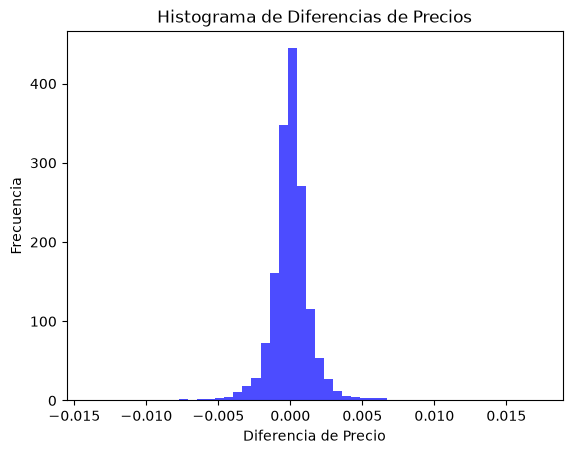

In [9]:
plt.hist(new_data_close["DiffPrice"], bins=50, color='blue', alpha=0.7, density=True)
plt.title("Histograma de Diferencias de Precios")
plt.xlabel("Diferencia de Precio")
plt.ylabel("Frecuencia")
plt.show()

(np.float64(14613.868594375072),
 np.float64(27361.660606098114),
 np.float64(-0.2096488866774875),
 np.float64(0.6022115067129248))

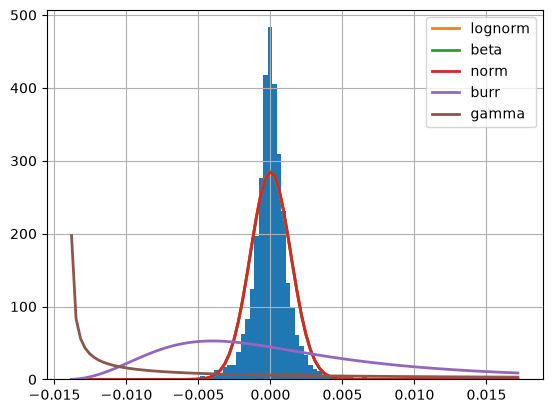

In [10]:
from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(new_data_close["DiffPrice"].dropna(),
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

## 7. Para el data frame, seleccionemos solo los datos del 2023.

In [11]:
new_index = []
for i in new_data_close.index:
    if "2023" in i:
        new_index.append(i)

new_data_2023 = new_data_close.loc[new_index]
new_data_2023

,Close,DiffPrice
time,,
2023-01-02 0:00:00,1.06796,-0.00200
2023-01-02 1:00:00,1.06965,0.00169
2023-01-02 2:00:00,1.07058,0.00093
2023-01-02 3:00:00,1.06896,-0.00162
2023-01-02 4:00:00,1.06880,-0.00016
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


## 8. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

In [12]:
new_data_2023.reset_index(inplace=True)
new_data_2023["time"] = pd.to_datetime(new_data_2023["time"])
new_data_2023.set_index("time", inplace=True)


new_data_2023.groupby(pd.Grouper(level='time', freq='15D')).mean()

,Close,DiffPrice
time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


In [13]:
#15 dias de periodicidad
D15_p = new_data_2023.groupby(pd.Grouper(level='time', freq='15D')).mean()

print("Periodicidad de 15 dias:")       
D15_p

Periodicidad de 15 dias:


,Close,DiffPrice
time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


In [14]:
W1_p = new_data_2023.groupby(pd.Grouper(level='time', freq='W')).mean()

print("Periodicidad de 1 semana:")
W1_p

Periodicidad de 1 semana:


,Close,DiffPrice
time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062
2023-02-12,1.073363,-0.000097
2023-02-19,1.069648,0.000014
2023-02-26,1.063374,-0.000124
2023-03-05,1.060854,0.000073


In [15]:
M1_p = new_data_2023.groupby(pd.Grouper(level='time', freq='ME')).mean()

print("Periodicidad de 1 mes:")
M1_p

Periodicidad de 1 mes:


,Close,DiffPrice
time,,
2023-01-31,1.077463,0.000031
2023-02-28,1.071167,-0.000060
2023-03-31,1.070874,0.000049
2023-04-30,1.096051,0.000036
2023-05-31,1.098980,-0.000069


## 9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes. Para ello puedo emplear el metodo groupby. 

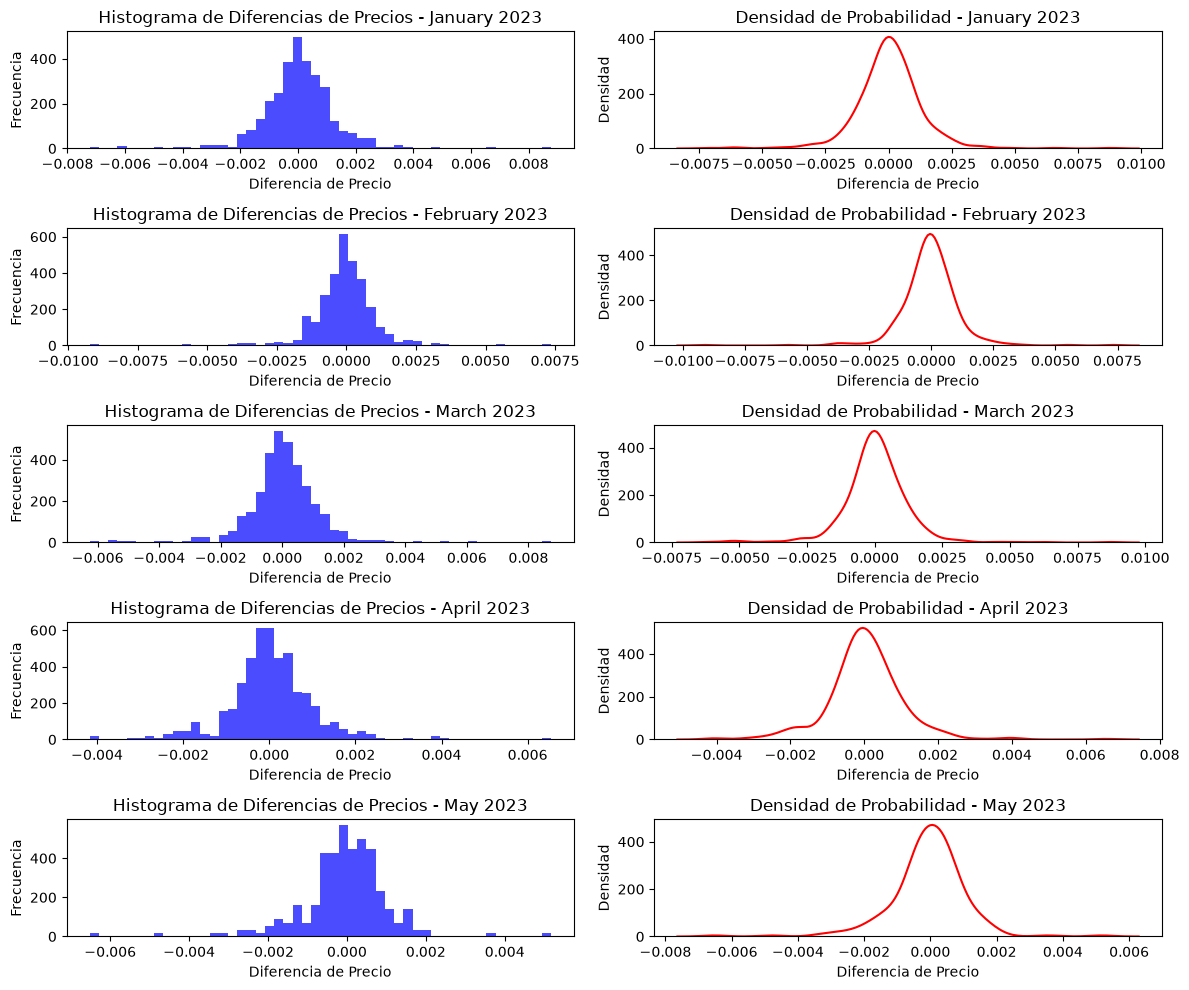

In [16]:
q=new_data_2023.groupby(pd.Grouper(level='time', freq='ME'))

names = []

groups = []

for name, group in q:
  names.append(name)
  groups.append(group["DiffPrice"])

fig, ax = plt.subplots(len(names),2, figsize=(12, 10))

for i in range(len(names)):
    ax[i,0].hist(groups[i], bins=50, color='blue', alpha=0.7, density=True)
    ax[i,0].set_title(f"Histograma de Diferencias de Precios - {names[i].strftime('%B %Y')}")
    ax[i,0].set_xlabel("Diferencia de Precio")
    ax[i,0].set_ylabel("Frecuencia")
    
    sns.kdeplot(groups[i], ax=ax[i,1], color='red')
    ax[i,1].set_title(f"Densidad de Probabilidad - {names[i].strftime('%B %Y')}")
    ax[i,1].set_xlabel("Diferencia de Precio")
    ax[i,1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

# Dataset cancer

## 1. Leer los datos desde una página web.

## 2. Renombrar las columnas en formato PascalCase.

In [79]:
# URL del archivo raw en el repositorio de la UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Nombres de las columnas
column_names = [
    'Id', 'Diagnosis', 
    'Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1',
    'Compactness1', 'Concavity1', 'ConcavePoint1', 'Symmetry1', 'FractalDimension1',
    'Radius2', 'Texture2', 'Perimeter2', 'Area2', 'Smoothness2',
    'Compactness2', 'Concavity2', 'ConcavePoints2', 'Symmetry2', 'FractalDimension2',
    'Radius3', 'Texture3', 'Perimeter3', 'Area3', 'Smoothness3',
    'Compactness3', 'Concavity3', 'ConcavePoints3', 'Symmetry3', 'FractalDimension3'
]

# Cargar el DataFrame directamente con pandas
df = pd.read_csv(url, header=None, names=column_names)

df

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## 3. Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.

In [80]:
df.head()

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [81]:
df.tail()

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [82]:
df.describe()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,Symmetry1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 569 non-null    int64  
 1   Diagnosis          569 non-null    str    
 2   Radius1            569 non-null    float64
 3   Texture1           569 non-null    float64
 4   Perimeter1         569 non-null    float64
 5   Area1              569 non-null    float64
 6   Smoothness1        569 non-null    float64
 7   Compactness1       569 non-null    float64
 8   Concavity1         569 non-null    float64
 9   ConcavePoint1      569 non-null    float64
 10  Symmetry1          569 non-null    float64
 11  FractalDimension1  569 non-null    float64
 12  Radius2            569 non-null    float64
 13  Texture2           569 non-null    float64
 14  Perimeter2         569 non-null    float64
 15  Area2              569 non-null    float64
 16  Smoothness2        569 non-null    fl

## 4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame. Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

In [84]:
dfnull = df.isnull().any()
dfnull_counts = df.isnull().sum()

dfnan = df.isna().any()
dfnan_counts = df.isna().sum()

nulos = pd.DataFrame({
    'Columnas con valores null': dfnull,
    'Cantidad de null': dfnull_counts,
    'Columnas con valores na': dfnan,
    'Cantidad de na': dfnan_counts
})

nulos

,Columnas con valores null,Cantidad de null,Columnas con valores na,Cantidad de na
Id,False,0,False,0
Diagnosis,False,0,False,0
Radius1,False,0,False,0
Texture1,False,0,False,0
Perimeter1,False,0,False,0
Area1,False,0,False,0
Smoothness1,False,0,False,0
Compactness1,False,0,False,0
Concavity1,False,0,False,0
ConcavePoint1,False,0,False,0


Para comparar el valor se podria comparar la fila en donde se encuentra el valor nulo y compararlo con alguna fila con datos aproximados y estimar el valor nulo con respecto a eso.

## 5. Identificar los valores únicos en la columna target que representan las etiquetas B y M (Benigno y Maligno, respectivamente). Utiliza el método unique() para mostrar estos valores.

In [85]:
df["Diagnosis"].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

## 6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot(): 

Text(0.5, 1.0, 'Distribución de Diagnósticos')

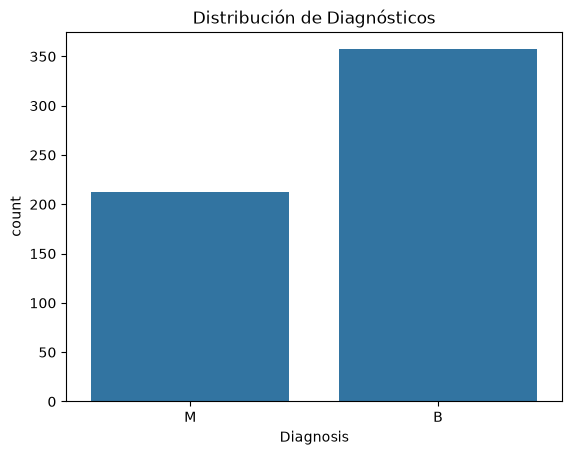

In [86]:
sns.countplot(x='Diagnosis', data = df)
plt.title("Distribución de Diagnósticos")

## 7. Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

In [87]:
df["DiagnosisNumeric"] = df["Diagnosis"].map({'M': 1, 'B': 0})

df[["Diagnosis", "DiagnosisNumeric"]]

,Diagnosis,DiagnosisNumeric
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1
...,...,...
564,M,1
565,M,1
566,M,1
567,M,1


## 8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:
$$(x - mean(x)) / std(x)$$

In [88]:
df_new = df.copy()
df_new.drop(columns=["Id", "Diagnosis","DiagnosisNumeric"], inplace=True)
df_new.columns

df_norm = df.copy()

for i in df_new.columns:
    df_norm[i] = (df_norm[i] - df_norm[i].mean()) / df_norm[i].std()

df_norm


,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,DiagnosisNumeric
0,842302,M,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,...,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,1
1,842517,M,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,...,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,1
2,84300903,M,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,...,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,1
3,84348301,M,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,...,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,1
4,84358402,M,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,...,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,2.109139,0.720838,2.058974,2.341795,1.040926,0.218868,1.945573,2.318924,...,0.117596,1.751022,2.013529,0.378033,-0.273077,0.663928,1.627719,-1.358963,-0.708467,1
565,926682,M,1.703356,2.083301,1.614511,1.722326,0.102368,-0.017817,0.692434,1.262558,...,2.045599,1.420690,1.493644,-0.690623,-0.394473,0.236365,0.733182,-0.531387,-0.973122,1
566,926954,M,0.701667,2.043775,0.672084,0.577445,-0.839745,-0.038646,0.046547,0.105684,...,1.373645,0.578492,0.427529,-0.808876,0.350427,0.326479,0.413705,-1.103578,-0.318129,1
567,927241,M,1.836725,2.334403,1.980781,1.733693,1.524426,3.269267,3.294046,2.656528,...,2.235958,2.301575,1.651717,1.429169,3.901415,3.194794,2.287972,1.917396,2.217684,1


## 9. Agrupar características similares y calcular su promedio. Para las siguientes características:

['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
Usa expresiones regulares para identificar patrones comunes, como radius1, radius2,radius3, etc., y calcular los promedios

In [89]:
import re

caract = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]

def set_mean(x):
    similarity = []
    norm = []

    for i in df_new.columns:
        if match in i:
            similarity.append(i)
            norm.append(df_norm[i].mean())
    return similarity, norm

print("los promedios para las caracteristicas pedidas son:")
for i in caract:
    match = re.match(r'^[A-Z][a-z]*', i ).group(0)
    similarity, means = set_mean(match)
    print(f"Característica: {match}:")
    for j in range(len(similarity)):
        print(f"  - Columna: {similarity[j]}, Promedio: {means[j]}")
    print("\n")




los promedios para las caracteristicas pedidas son:
Característica: Radius:
  - Columna: Radius1, Promedio: -1.3111948550933307e-16
  - Columna: Radius2, Promedio: 2.4975140097015826e-16
  - Columna: Radius3, Promedio: -8.241796232015222e-16


Característica: Texture:
  - Columna: Texture1, Promedio: 6.243785024253956e-17
  - Columna: Texture2, Promedio: -1.123881304365712e-16
  - Columna: Texture3, Promedio: 1.2487570048507911e-17


Característica: Perimeter:
  - Columna: Perimeter1, Promedio: -1.2487570048507913e-16
  - Columna: Perimeter2, Promedio: -1.3736327053358703e-16
  - Columna: Perimeter3, Promedio: -3.496519613582215e-16


Característica: Area:
  - Columna: Area1, Promedio: -2.1853247584888846e-16
  - Columna: Area2, Promedio: -1.1863191546082517e-16
  - Columna: Area3, Promedio: 0.0


Característica: Smoothness:
  - Columna: Smoothness1, Promedio: -8.366671932500301e-16
  - Columna: Smoothness2, Promedio: -1.545336793502854e-16
  - Columna: Smoothness3, Promedio: -2.122886

## 10. Crear un gráfico donde se muestre el histograma de la columna RadiusMean separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

<Axes: xlabel='Radius1', ylabel='Count'>

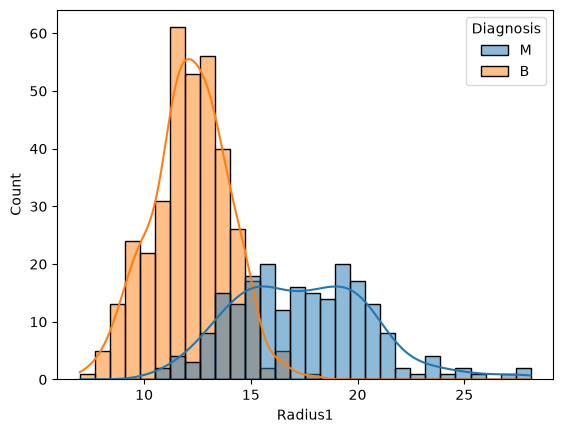

In [91]:
sns.histplot(data = df, x="Radius1", hue="Diagnosis", bins=30, kde=True)

## 11. Generar gráficos de violín para múltiples características. Para las columnas:

- RadiusMean
- TextureMean
- PerimeterMean
- AreaMean
- SmoothnessMean
- CompactnessMean
- ConcavityMean
- ConcavePointsMean
- Symmetry3
- FractalDimension3

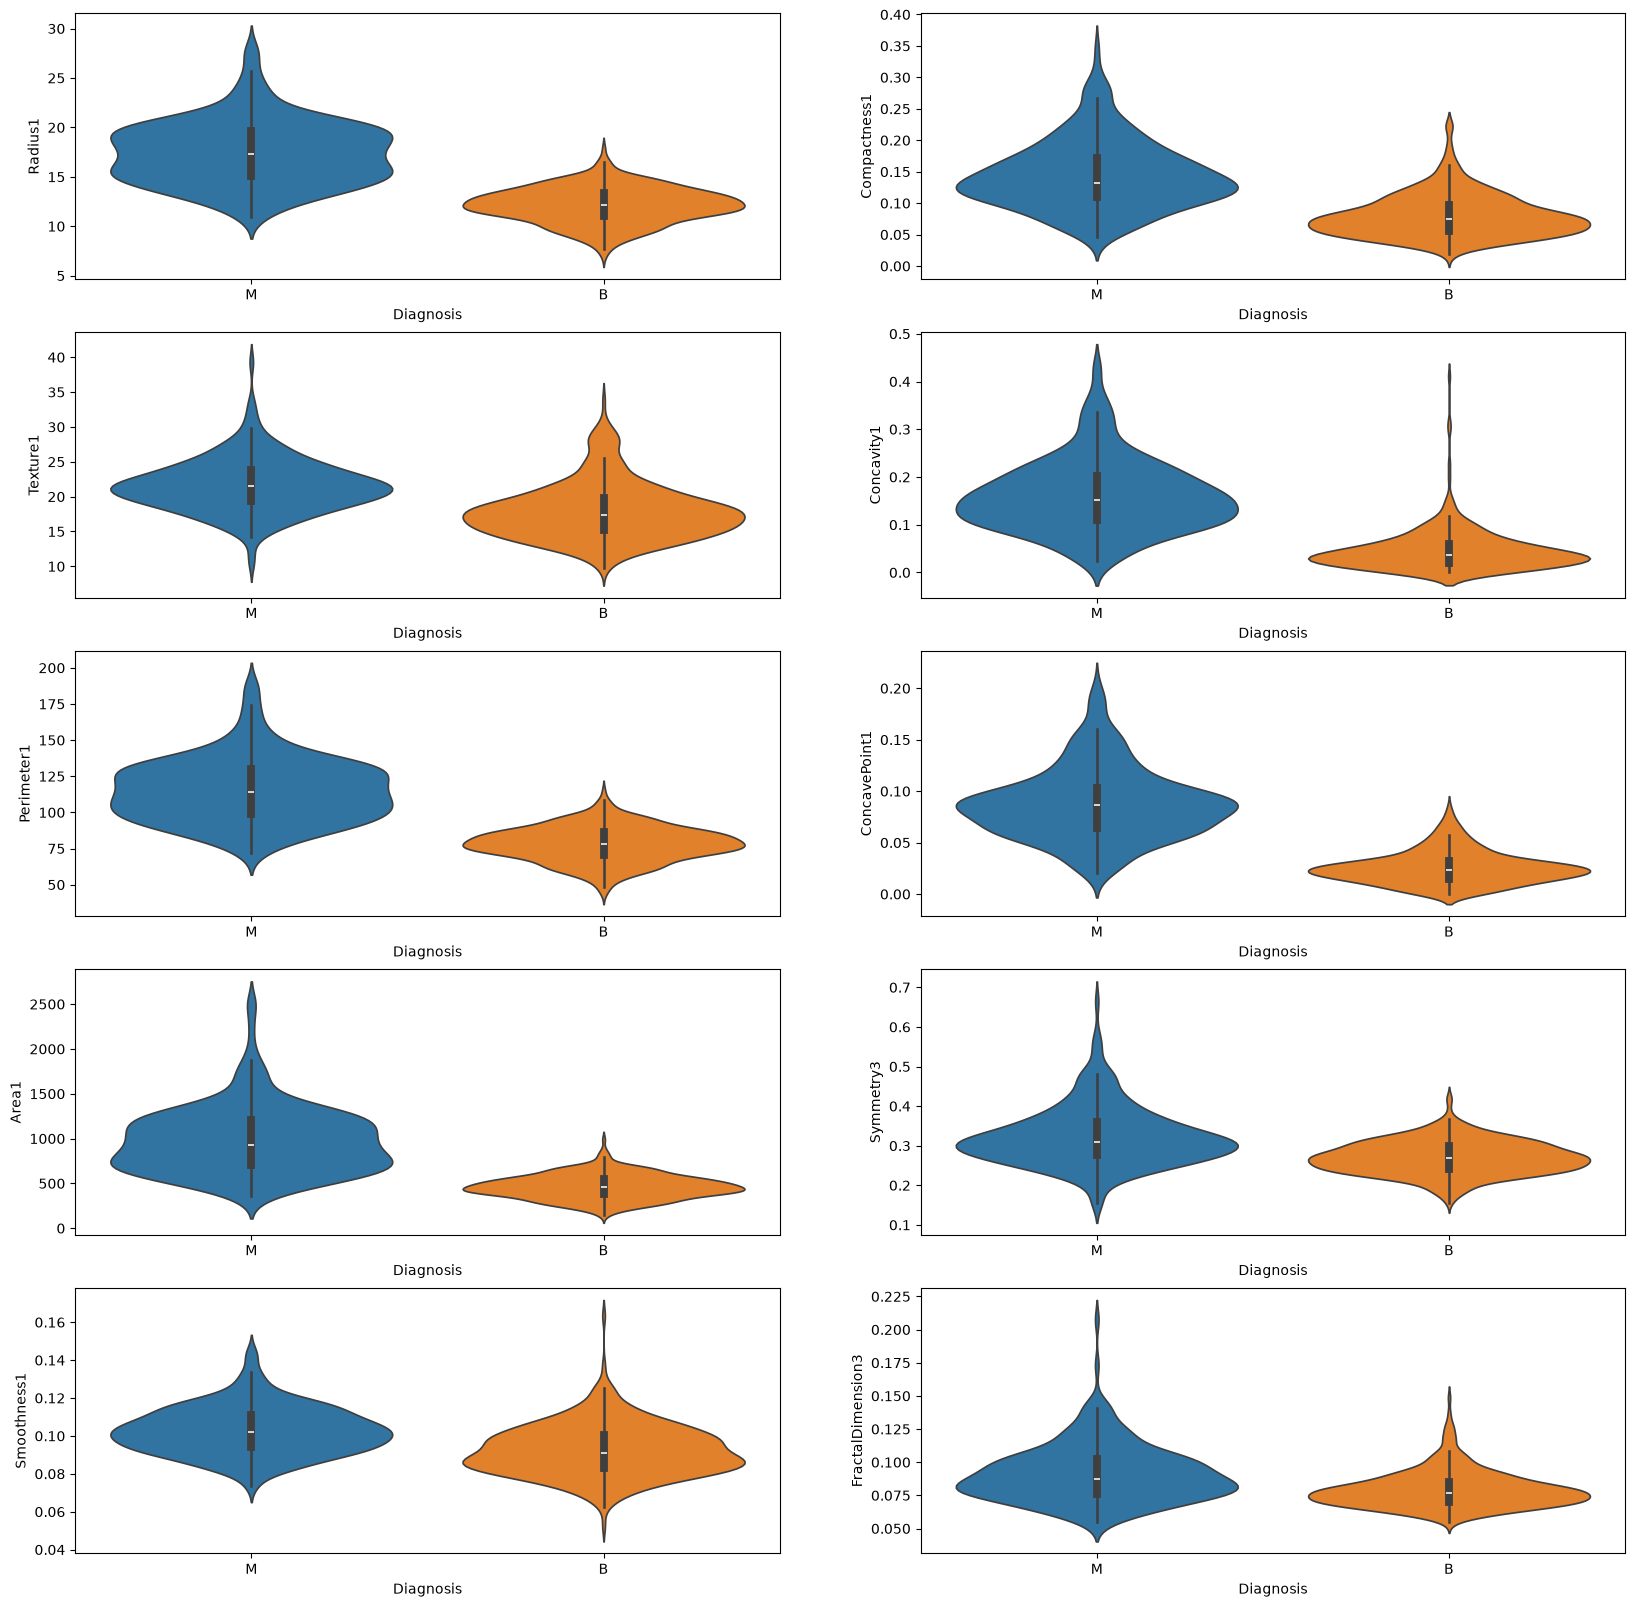

In [148]:
columnas = ['Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1', 'Compactness1', 'Concavity1', 'ConcavePoint1', "Symmetry3", "FractalDimension3"]
fig, axes = plt.subplots(int((len(columnas))/2), 2, figsize=(20, 20))
for i in range(len(columnas)):
    if i < 5:
      sns.violinplot(x="Diagnosis", y=columnas[i], data=df,ax = axes[i,0], hue="Diagnosis")
    else:
      sns.violinplot(x="Diagnosis", y=columnas[i], data=df,ax = axes[i-5,1], hue="Diagnosis")

## 12. Determinar y eliminar los valores atípicos (outliers) en la columna RadiusMean.

<Axes: xlabel='Diagnosis', ylabel='Radius1'>

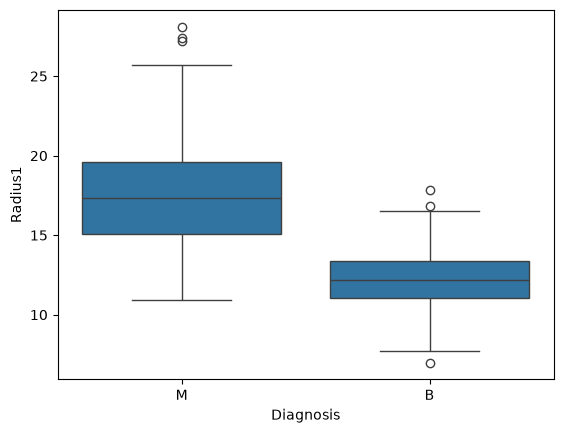

In [165]:
sns.boxplot(data = df, x='Diagnosis', y='Radius1')

In [168]:
Q1 = df['Radius1'].quantile(0.25)
Q3 = df['Radius1'].quantile(0.75)
IQR = Q3 - Q1

df_notat = df.copy()
df_at = df.copy()
df_notat = df[~((df['Radius1'] < (Q1 - 1.5 * IQR)) | (df['Radius1'] > (Q3 + 1.5 * IQR)))]
df_at = df[~((df['Radius1'] >= (Q1 - 1.5 * IQR)) & (df['Radius1'] <= (Q3 + 1.5 * IQR)))]


In [169]:
#dataframe con los valores atipicos
df_at 

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,DiagnosisNumeric
82,8611555,M,25.22,24.91,171.5,1878.0,0.10630,0.2665,0.3339,0.18450,...,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510,1
108,86355,M,22.27,19.67,152.8,1509.0,0.13260,0.2768,0.4264,0.18230,...,28.01,206.8,2360.0,0.1701,0.6997,0.9608,0.2910,0.4055,0.09789,1
122,865423,M,24.25,20.20,166.2,1761.0,0.14470,0.2867,0.4268,0.20120,...,23.99,180.9,2073.0,0.1696,0.4244,0.5803,0.2248,0.3222,0.08009,1
164,8712289,M,23.27,22.04,152.1,1686.0,0.08439,0.1145,0.1324,0.09702,...,28.22,184.2,2403.0,0.1228,0.3583,0.3948,0.2346,0.3589,0.09187,1
180,873592,M,27.22,21.87,182.1,2250.0,0.10940,0.1914,0.2871,0.18780,...,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082,1
202,878796,M,23.29,26.67,158.9,1685.0,0.11410,0.2084,0.3523,0.16200,...,32.68,177.0,1986.0,0.1536,0.4167,0.7892,0.2733,0.3198,0.08762,1
212,8810703,M,28.11,18.47,188.5,2499.0,0.11420,0.1516,0.3201,0.15950,...,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525,1
236,88299702,M,23.21,26.97,153.5,1670.0,0.09509,0.1682,0.1950,0.12370,...,34.51,206.0,2944.0,0.1481,0.4126,0.5820,0.2593,0.3103,0.08677,1
339,89812,M,23.51,24.27,155.1,1747.0,0.10690,0.1283,0.2308,0.14100,...,30.73,202.4,2906.0,0.1515,0.2678,0.4819,0.2089,0.2593,0.07738,1
352,899987,M,25.73,17.46,174.2,2010.0,0.11490,0.2363,0.3368,0.19130,...,23.58,229.3,3234.0,0.1530,0.5937,0.6451,0.2756,0.3690,0.08815,1


In [170]:
#dataframe sin los valores atipicos
df_notat

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,DiagnosisNumeric
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


## 13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoint1,Symmetry1,FractalDimension1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


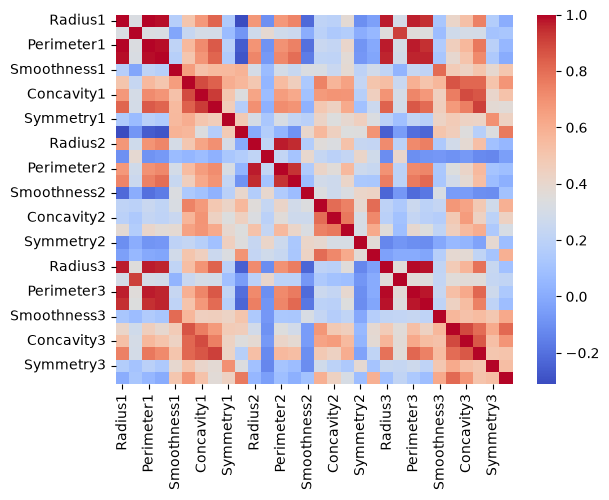

In [ ]:
matriz = df_new.corr()
sns.heatmap(matriz, cmap='coolwarm')

## 14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?

Principalmente graficos de dispersion entre variables seprando los datos mediante la columna de Diagnosis

<Axes: xlabel='Radius1', ylabel='Texture1'>

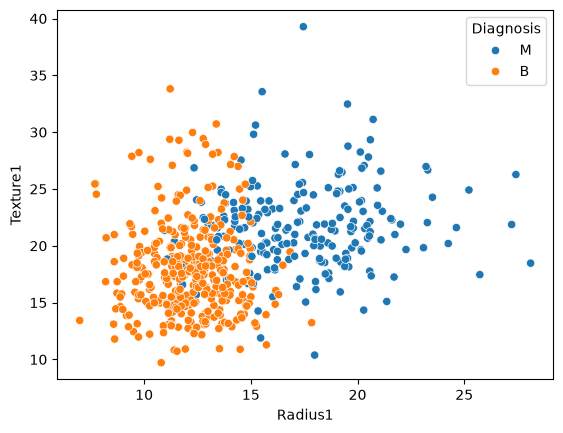

In [174]:
sns.scatterplot(data = df, x='Radius1', y='Texture1', hue='Diagnosis')